# Análisis Multivariable de Datos - Diabetes

### By:
Maria Camila Aristizábal Aguirre

### Date:
2026-08-17


## 📚 Import  libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR = Path("../../data")

## 💾 Load data

In [2]:
df = pd.read_parquet(DATA_DIR / "02_intermediate" / "diabetes_type_fixed.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               986 non-null    Int8   
 1   Glucose                   982 non-null    float64
 2   BloodPressure             942 non-null    float64
 3   SkinThickness             689 non-null    float64
 4   Insulin                   501 non-null    float64
 5   BMI                       978 non-null    float64
 6   DiabetesPedigreeFunction  989 non-null    float64
 7   Age                       991 non-null    Int8   
 8   Outcome                   975 non-null    boolean
dtypes: Int8(2), boolean(1), float64(6)
memory usage: 52.5 KB


## Alcance de este análisis

Este dataset de diabetes no tiene
ninguna variable categórica predictora (las 8 features son numéricas), por lo que
se adapta el análisis multivariable a lo que sí aplica:

- **Pairplot**: relaciones entre todas las variables numéricas, coloreadas por `Outcome`.
- **Tabla de agregación por bins**: en vez de agrupar por clase (categórica, como en
  Titanic), se agrupan dos variables numéricas en rangos (Age y BMI) para ver si la
  combinación de ambas concentra una tasa de `Outcome` positivo más alta que cada
  variable por separado.


In [3]:
DATA_INTERMEDIA = Path("../../data/02_intermediate/diabetes_type_fixed.parquet")
df = pd.read_parquet(DATA_INTERMEDIA)

df_con_outcome = df[df["Outcome"].notna()].copy()
df_con_outcome["Outcome"] = df_con_outcome["Outcome"].astype(bool)

COLUMNAS_NUMERICAS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

## Pairplot: relaciones multivariables por Outcome

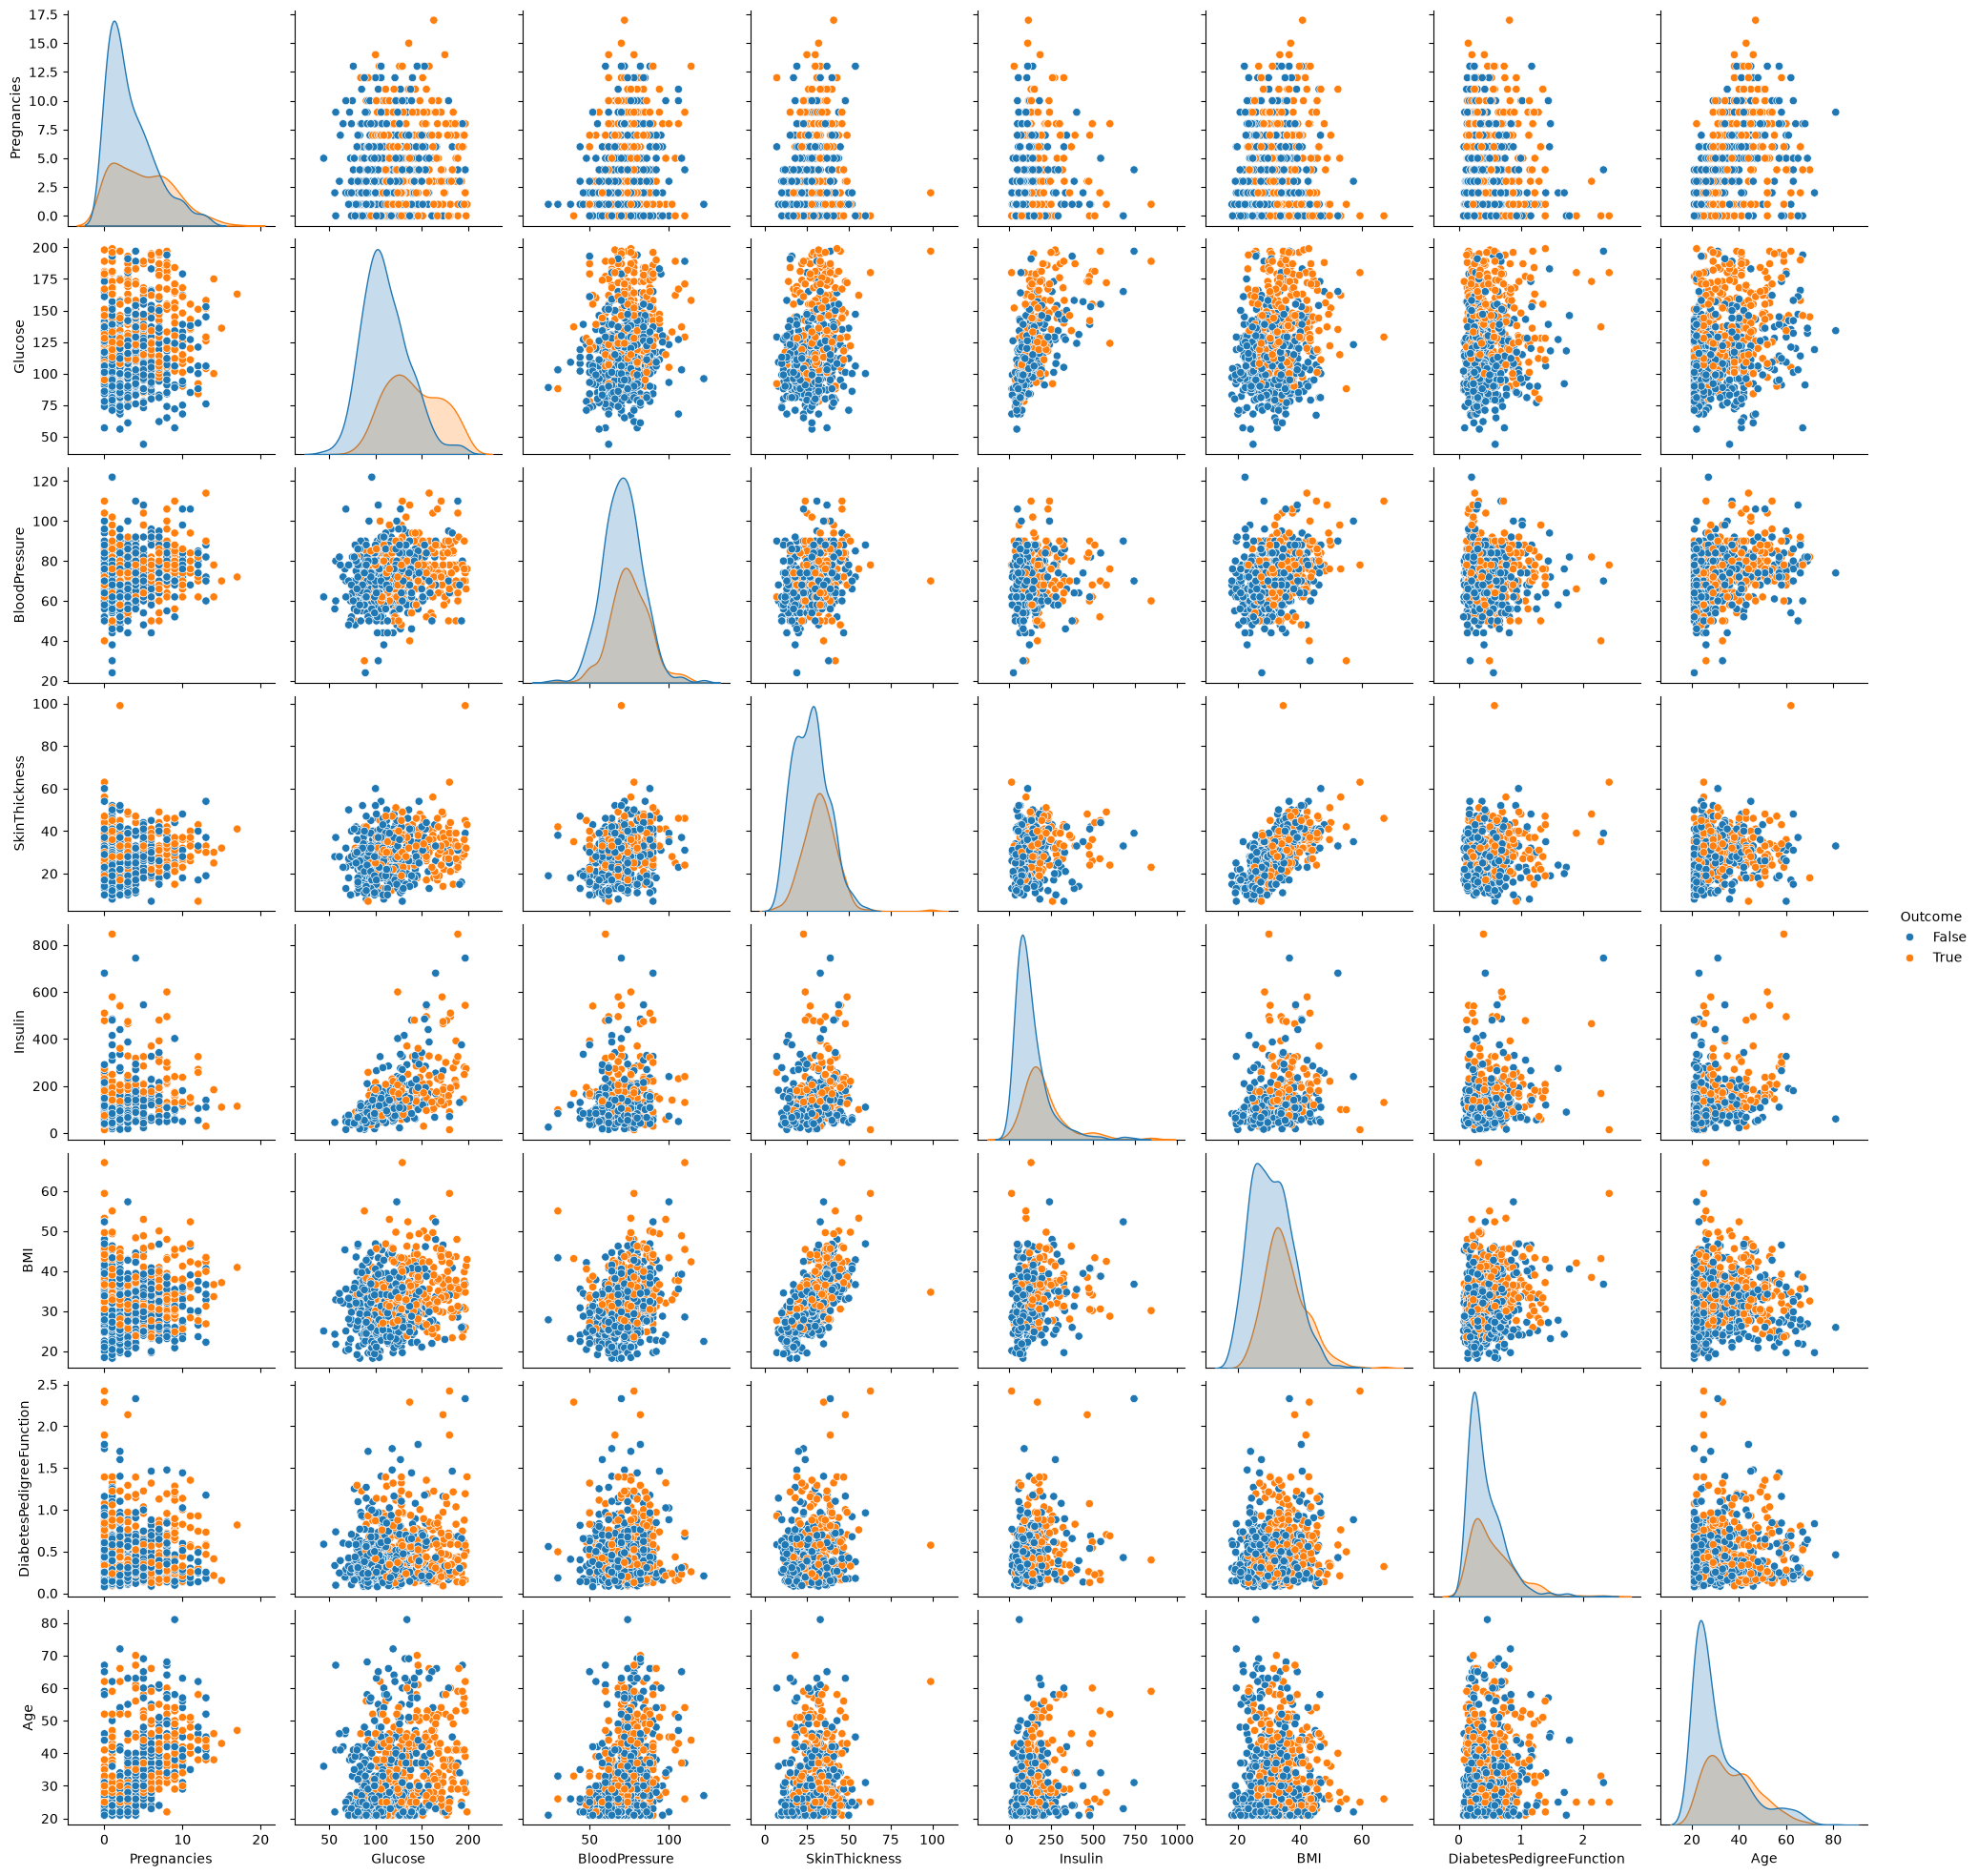

In [4]:
sns.pairplot(
    df_con_outcome[[*COLUMNAS_NUMERICAS, "Outcome"]],
    hue="Outcome",
    diag_kind="kde",
)
plt.show()

## Tabla de agregación: grupos de Edad × grupos de BMI vs tasa de Outcome positivo


In [5]:
BINS_EDAD = [20, 30, 40, 50, 100]
ETIQUETAS_EDAD = ["20-29", "30-39", "40-49", "50+"]

BINS_BMI = [0, 18.5, 25, 30, 100]
ETIQUETAS_BMI = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]

df_con_outcome["Age_grupo"] = pd.cut(
    df_con_outcome["Age"], bins=BINS_EDAD, labels=ETIQUETAS_EDAD, right=False
)
df_con_outcome["BMI_grupo"] = pd.cut(
    df_con_outcome["BMI"], bins=BINS_BMI, labels=ETIQUETAS_BMI, right=False
)

tabla_multivariable = (
    df_con_outcome.groupby(["Age_grupo", "BMI_grupo"], observed=True)["Outcome"]
    .agg(tasa_outcome_positivo="mean", n="count")
    .reset_index()
)
tabla_multivariable

,Age_grupo,BMI_grupo,tasa_outcome_positivo,n
0,20-29,Bajo peso,0.00,5
1,20-29,Normal,0.01,79
2,20-29,Sobrepeso,0.13,126
3,20-29,Obesidad,0.34,275
4,30-39,Normal,0.10,20
5,30-39,Sobrepeso,0.27,48
6,30-39,Obesidad,0.56,141
7,40-49,Normal,0.00,7
8,40-49,Sobrepeso,0.59,22
9,40-49,Obesidad,0.57,122


In [6]:
tabla_pivote_pct = (
    tabla_multivariable.pivot(
        index="Age_grupo", columns="BMI_grupo", values="tasa_outcome_positivo"
    )
    * 100
).round(1)
tabla_pivote_pct

BMI_grupo,Bajo peso,Normal,Sobrepeso,Obesidad
Age_grupo,,,,
20-29,0.00,1.30,12.70,34.20
30-39,NaN,10.00,27.10,56.00
40-49,NaN,0.00,59.10,57.40
50+,NaN,27.30,31.00,63.30


In [7]:
tabla_conteo = tabla_multivariable.pivot(index="Age_grupo", columns="BMI_grupo", values="n")
tabla_conteo

BMI_grupo,Bajo peso,Normal,Sobrepeso,Obesidad
Age_grupo,,,,
20-29,5.00,79.00,126.00,275.00
30-39,NaN,20.00,48.00,141.00
40-49,NaN,7.00,22.00,122.00
50+,NaN,22.00,29.00,60.00


## Hallazgos - Análisis multivariable

### Pairplot

- **Glucose** es, de nuevo, la variable con la separación más clara entre `Outcome=True`
  y `Outcome=False` en su curva de densidad diagonal, confirmando el hallazgo del
  análisis bivariable.
- En el panel **Glucose vs. Insulin** se observa una relación positiva clara (coherente
  con la correlación de 0.58 vista en el heatmap), y los puntos naranjas (`Outcome=True`)
  se concentran más hacia la zona de valores altos de ambas variables.
- En el panel **SkinThickness vs. BMI** se confirma la relación positiva más fuerte del
  dataset (correlación 0.66): a mayor grosor de piel, mayor BMI, sin diferencia marcada
  de color entre clases en ese eje.
- En el panel **Pregnancies vs. Age** se ve la relación positiva esperada
  (correlación 0.55).
- No se observa ningún par de variables que separe visualmente a las dos clases con una
  frontera limpia (no hay un "cluster" 2D puro de una sola clase); esto sugiere que
  ninguna combinación simple de dos variables por sí sola discrimina bien el Outcome,
  y refuerza la necesidad de un modelo multivariable en vez de una regla
  heurística simple de 1-2 variables.
- El outlier extremo de **SkinThickness (~99)** identificado en el análisis univariable
  es visible de forma aislada en varios paneles (ej. SkinThickness vs. BMI, SkinThickness
  vs. Insulin), confirmando que sigue pendiente de tratamiento en Feature Engineering.

### Tabla Age × BMI vs. tasa de Outcome positivo

| Age_grupo | Bajo peso | Normal | Sobrepeso | Obesidad |
|---|---|---|---|---|
| 20-29 | 0.0% (n=5) | 1.3% (n=79) | 12.7% (n=126) | 34.2% (n=275) |
| 30-39 | — (n=0) | 10.0% (n=20) | 27.1% (n=48) | 56.0% (n=141) |
| 40-49 | — (n=0) | 0.0% (n=7) | 59.1% (n=22) | 57.4% (n=122) |
| 50+ | — (n=0) | 27.3% (n=22) | 31.0% (n=29) | 63.3% (n=60) |

- La categoría **Obesidad** muestra un incremento prácticamente monótono de la tasa de
  Outcome positivo con la edad: 34.2% (20-29) → 56.0% (30-39) → 57.4% (40-49) → 63.3%
  (50+), con tamaños de muestra razonables en todas las celdas (n≥60). Esto sugiere que
  edad y obesidad tienen un efecto que se acumula, aunque su correlación lineal directa
  es prácticamente nula (BMI-Age = 0.04 en el heatmap bivariable) — es decir, no es que
  BMI y Age estén correlacionadas entre sí, sino que cada una aporta riesgo de forma
  aparentemente independiente.
- La celda **Normal / 40-49 con tasa 0.0%** tiene una muestra muy pequeña (n=7) y no debe
  interpretarse como un patrón real; es ruido estadístico por bajo n.
- La categoría **Bajo peso** es casi inexistente en este dataset (solo 5 registros, todos
  en 20-29 años), consistente con tratarse de una población de mujeres evaluadas por
  riesgo de diabetes, donde el bajo peso es poco común.
- 956 de los 975 registros con Outcome conocido entraron en esta tabla; los ~19 restantes
  se excluyeron por tener `BMI` faltante (aún sin imputar).